# Raça, Renda e Acesso ao Ensino Superior
### Regressão Logística Multinomial — Microdados ENADE 2017

**Variável resposta (Y):**
| Código | Descrição | Y |
|---|---|---|
| 4 e 5 | Privada | 0 — base |
| 1 | Pública Federal | 1 |
| 2 e 3 | Pública Estadual/Municipal | 2 |

**Variáveis explicativas:**
- `RACA` — Branca / Preta / Indígena / Outras (referência)
- `RENDA` — Baixa ≤3 SM / Média 3–10 SM / Alta >10 SM (referência)
- `RACA × RENDA` — interação para capturar efeito combinado

---
## 0. Dependências

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

---
## 1. Importação e Filtro

In [4]:
df_raw = pd.read_parquet('Enade2017.parquet')

# Apenas concluintes presentes
df = df_raw[df_raw['TP_PRES'] == 555][[
    'CO_CATEGAD', 'QE_I02', 'QE_I08'
]].copy()

print(f'Observações após filtro de presença: {len(df):,}')

Observações após filtro de presença: 450,061


---
## 2. Recodificação das Variáveis

### 2.1 Variável Resposta — Y

In [5]:
df['Y'] = df['CO_CATEGAD'].map({1: 1, 2: 2, 3: 2, 4: 0, 5: 0})
df = df[df['Y'].notna()].copy()
df['Y'] = df['Y'].astype(int)

### 2.2 Raça — QE_I02

| Original | Descrição | Grupo |
|---|---|---|
| A | Branca | `Branca` |
| B | Preta | `Preta` |
| C | Amarela | `Outras` (ref.) |
| D | Parda | `Outras` (ref.) |
| E | Indígena | `Indigena` |
| F | Não declarou | removida |

In [6]:
raca_map = {'A': 'Branca', 'B': 'Preta', 'C': 'Outras', 'D': 'Outras', 'E': 'Indigena'}
df['RACA'] = df['QE_I02'].map(raca_map)

# Remove não declarou (F) e missings
df = df[df['RACA'].notna()].copy()

print('Distribuição de Raça:')
print(df['RACA'].value_counts())
print()
print(df['RACA'].value_counts(normalize=True).round(3))

Distribuição de Raça:
RACA
Branca      229000
Outras      156516
Preta        41450
Indigena      1804
Name: count, dtype: int64

RACA
Branca     0.5340
Outras     0.3650
Preta      0.0970
Indigena   0.0040
Name: proportion, dtype: float64


### 2.3 Renda — QE_I08

| Original | Faixa | Grupo |
|---|---|---|
| A | Até 1,5 SM | `Baixa` |
| B | 1,5 a 3 SM | `Baixa` |
| C | 3 a 4,5 SM | `Media` |
| D | 4,5 a 6 SM | `Media` |
| E | 6 a 10 SM | `Media` |
| F | 10 a 30 SM | `Alta` |
| G | Acima de 30 SM | `Alta` |

In [7]:
renda_map = {'A': 'Baixa', 'B': 'Baixa', 'C': 'Media',
             'D': 'Media', 'E': 'Media', 'F': 'Alta', 'G': 'Alta'}
df['RENDA'] = df['QE_I08'].map(renda_map)
df = df[df['RENDA'].notna()].copy()

print('Distribuição de Renda:')
print(df['RENDA'].value_counts())
print()
print(df['RENDA'].value_counts(normalize=True).round(3))

Distribuição de Renda:
RENDA
Baixa    221005
Media    178476
Alta      29289
Name: count, dtype: int64

RENDA
Baixa   0.5150
Media   0.4160
Alta    0.0680
Name: proportion, dtype: float64


---
## 3. Análise Exploratória

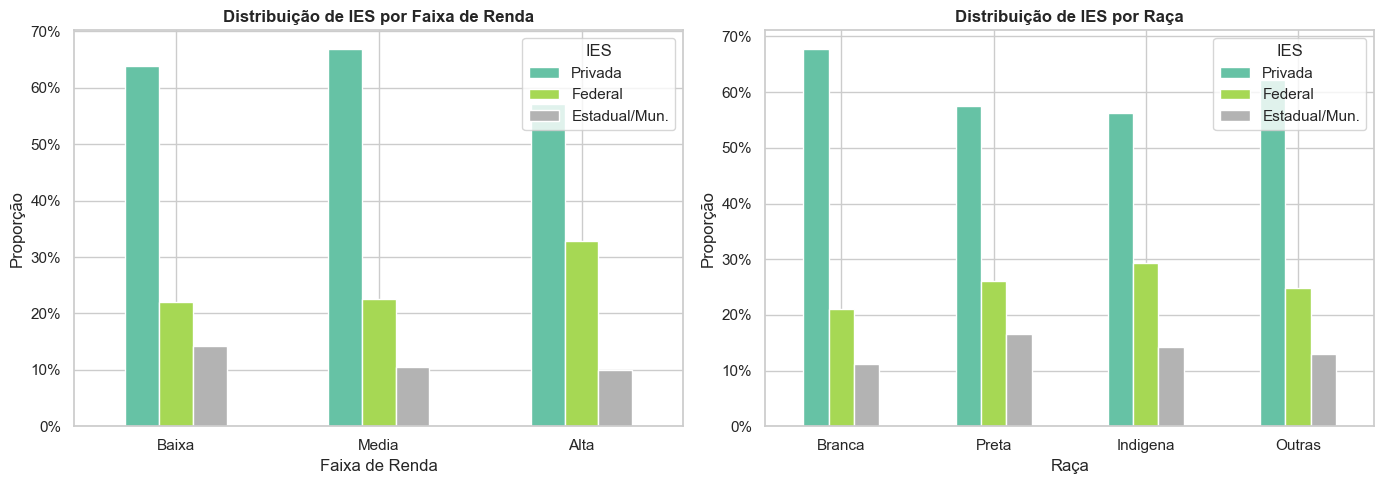

In [8]:
ies_labels  = {0: 'Privada', 1: 'Federal', 2: 'Estadual/Mun.'}
renda_order = ['Baixa', 'Media', 'Alta']
raca_order  = ['Branca', 'Preta', 'Indigena', 'Outras']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: proporção de cada IES por faixa de renda ---
renda_ies = (df.groupby('RENDA')['Y']
               .value_counts(normalize=True)
               .unstack(fill_value=0)
               .rename(columns=ies_labels)
               .loc[renda_order])

renda_ies.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Distribuição de IES por Faixa de Renda', fontweight='bold')
axes[0].set_xlabel('Faixa de Renda')
axes[0].set_ylabel('Proporção')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].legend(title='IES')

# --- Plot 2: proporção de cada IES por raça ---
raca_ies = (df.groupby('RACA')['Y']
              .value_counts(normalize=True)
              .unstack(fill_value=0)
              .rename(columns=ies_labels)
              .loc[raca_order])

raca_ies.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Distribuição de IES por Raça', fontweight='bold')
axes[1].set_xlabel('Raça')
axes[1].set_ylabel('Proporção')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].legend(title='IES')

plt.tight_layout()
plt.show()

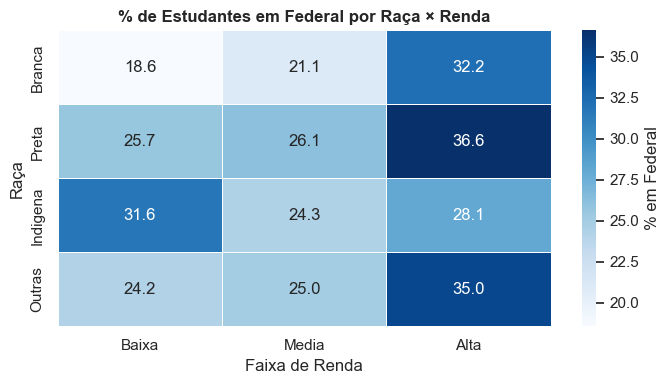

In [9]:
# Heatmap: % em Federal cruzando raça × renda
federal_pct = (df[df['Y'] == 1]
               .groupby(['RACA', 'RENDA']).size()
               .div(df.groupby(['RACA', 'RENDA']).size())
               .unstack()
               .loc[raca_order, renda_order] * 100)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(federal_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% em Federal'})
ax.set_title('% de Estudantes em Federal por Raça × Renda', fontweight='bold')
ax.set_xlabel('Faixa de Renda')
ax.set_ylabel('Raça')
plt.tight_layout()
plt.show()

---
## 4. Modelagem

### 4.1 Criação das Dummies

- **Referência de Raça:** `Outras` (Amarela + Parda)
- **Referência de Renda:** `Alta` (>10 SM)

A categoria de referência é sempre o grupo mais numeroso/neutro — os OR serão interpretados *em relação a ele*.

In [10]:
# Dummies com categoria de referência explícita
df['RACA_Branca']   = (df['RACA'] == 'Branca').astype(int)
df['RACA_Preta']    = (df['RACA'] == 'Preta').astype(int)
df['RACA_Indigena'] = (df['RACA'] == 'Indigena').astype(int)
# Referência: Outras (Amarela + Parda)

df['RENDA_Baixa']   = (df['RENDA'] == 'Baixa').astype(int)
df['RENDA_Media']   = (df['RENDA'] == 'Media').astype(int)
# Referência: Alta

# Termos de interação: raça × renda
for raca in ['Branca', 'Preta', 'Indigena']:
    for renda in ['Baixa', 'Media']:
        df[f'{raca}_x_{renda}'] = df[f'RACA_{raca}'] * df[f'RENDA_{renda}']

X_cols = [
    'RACA_Branca', 'RACA_Preta', 'RACA_Indigena',
    'RENDA_Baixa', 'RENDA_Media',
    'Branca_x_Baixa', 'Branca_x_Media',
    'Preta_x_Baixa',  'Preta_x_Media',
    'Indigena_x_Baixa', 'Indigena_x_Media'
]

df_model = df[['Y'] + X_cols].dropna()
print(f'Dataset para modelagem: {len(df_model):,} observações')

Dataset para modelagem: 428,770 observações


### 4.2 Estimação — Modelo Sem Interação (M1) e Com Interação (M2)

In [11]:
Y = df_model['Y'].astype(int)

# M1 — efeitos principais apenas
X1 = sm.add_constant(df_model[['RACA_Branca','RACA_Preta','RACA_Indigena',
                                 'RENDA_Baixa','RENDA_Media']])
m1 = MNLogit(Y, X1).fit(method='bfgs', maxiter=1000, disp=False)

# M2 — efeitos principais + interações raça × renda
X2 = sm.add_constant(df_model[X_cols])
m2 = MNLogit(Y, X2).fit(method='bfgs', maxiter=1000, disp=False)

print(f'M1 | AIC: {m1.aic:,.1f} | Pseudo-R²: {m1.prsquared:.4f}')
print(f'M2 | AIC: {m2.aic:,.1f} | Pseudo-R²: {m2.prsquared:.4f}')

M1 | AIC: 748,225.0 | Pseudo-R²: 0.0072
M2 | AIC: 747,715.5 | Pseudo-R²: 0.0079


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X1, Y, test_size=0.2, random_state=42)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')
print(f'Treino: {len(y_train):,} | Teste: {len(y_test):,}')

Treino: 343,016 | Teste: 85,754
Treino: 343,016 | Teste: 85,754


In [17]:
model = sm.MNLogit(y_train, sm.add_constant(X_train))
results = model.fit()

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.873563
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:                      Y   No. Observations:               343016
Model:                        MNLogit   Df Residuals:                   343004
Method:                           MLE   Df Model:                           10
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                0.007212
Time:                        01:13:12   Log-Likelihood:            -2.9965e+05
converged:                       True   LL-Null:                   -3.0182e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
          Y=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.3229      0.016    -20.244      0.000      -0.354      -0.292
RACA_Branca      -0.

In [18]:
def residuos_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    desviance_residuals = -2 * (y_true * np.log(y_true / y_pred))
    desviance_residuals[np.isnan(desviance_residuals)] = 0
    return desviance_residuals

In [19]:
y_train_onehot = pd.get_dummies(y_train).values
y_train_onehot

array([[ True, False, False],
       [False, False,  True],
       [ True, False, False],
       ...,
       [ True, False, False],
       [ True, False, False],
       [ True, False, False]], shape=(343016, 3))

### 4.3 Teste de Razão de Verossimilhança — M1 vs M2

Verifica se as interações melhoram significativamente o ajuste.

In [20]:
from scipy import stats

lrt_stat = -2 * (m1.llf - m2.llf)
df_diff  = m2.df_model - m1.df_model
p_lrt    = stats.chi2.sf(lrt_stat, df=df_diff)

print('=== Teste de Razão de Verossimilhança ===')
print(f'Estatística LRT : {lrt_stat:.2f}')
print(f'Graus de liberdade: {df_diff}')
print(f'p-valor         : {p_lrt:.6f}')
print(f'Conclusão       : {"Interações significativas (***)" if p_lrt < 0.001 else "Interações não significativas"}')

=== Teste de Razão de Verossimilhança ===
Estatística LRT : 533.52
Graus de liberdade: 12.0
p-valor         : 0.000000
Conclusão       : Interações significativas (***)


---
## 5. Odds Ratios e Interpretação

### 5.1 Tabela de OR — M1 (efeitos principais)

In [22]:
def or_table(model, cat=0, label='Federal vs Privada'):
    """
    cat=0 → Federal vs Privada
    cat=1 → Estadual/Mun. vs Privada
    """
    params  = model.params.iloc[:, cat]
    pvalues = model.pvalues.iloc[:, cat]
    conf    = model.conf_int(alpha=0.05)
    ci_lo   = conf['lower']
    ci_hi   = conf['upper']

    t = pd.DataFrame({
        'OR':       np.exp(params),
        'IC 2.5%':  np.exp(ci_lo),
        'IC 97.5%': np.exp(ci_hi),
        'p-valor':  pvalues
    }).drop(index='const', errors='ignore')

    t['Sig.'] = t['p-valor'].apply(
        lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    )
    print(f'\n--- {label} ---')
    return t.round(4)

print('=== MODELO M1 — Efeitos Principais ===')
display(or_table(m1, cat=0, label='Federal vs Privada'))
display(or_table(m1, cat=1, label='Estadual/Municipal vs Privada'))

=== MODELO M1 — Efeitos Principais ===

--- Federal vs Privada ---


,OR,IC 2.5%,IC 97.5%,p-valor,Sig.
"(1, RACA_Branca)",NaN,0.7281,0.7517,NaN,ns
"(1, RACA_Indigena)",NaN,1.1797,1.4579,NaN,ns
"(1, RACA_Preta)",NaN,1.1162,1.1749,NaN,ns
"(1, RENDA_Baixa)",NaN,0.5176,0.5471,NaN,ns
"(1, RENDA_Media)",NaN,0.5434,0.5743,NaN,ns
"(1, const)",NaN,0.7007,0.7411,NaN,ns
"(2, RACA_Branca)",NaN,0.8124,0.8464,NaN,ns
"(2, RACA_Indigena)",NaN,1.0440,1.3744,NaN,ns
"(2, RACA_Preta)",NaN,1.3180,1.4020,NaN,ns
"(2, RENDA_Baixa)",NaN,1.1001,1.1956,NaN,ns



--- Estadual/Municipal vs Privada ---


,OR,IC 2.5%,IC 97.5%,p-valor,Sig.
"(1, RACA_Branca)",NaN,0.7281,0.7517,NaN,ns
"(1, RACA_Indigena)",NaN,1.1797,1.4579,NaN,ns
"(1, RACA_Preta)",NaN,1.1162,1.1749,NaN,ns
"(1, RENDA_Baixa)",NaN,0.5176,0.5471,NaN,ns
"(1, RENDA_Media)",NaN,0.5434,0.5743,NaN,ns
"(1, const)",NaN,0.7007,0.7411,NaN,ns
"(2, RACA_Branca)",NaN,0.8124,0.8464,NaN,ns
"(2, RACA_Indigena)",NaN,1.0440,1.3744,NaN,ns
"(2, RACA_Preta)",NaN,1.3180,1.4020,NaN,ns
"(2, RENDA_Baixa)",NaN,1.1001,1.1956,NaN,ns


### 5.2 Tabela de OR — M2 (com interações)

In [23]:
print('=== MODELO M2 — Com Interações Raça × Renda ===')
display(or_table(m2, cat=0, label='Federal vs Privada'))
display(or_table(m2, cat=1, label='Estadual/Municipal vs Privada'))

=== MODELO M2 — Com Interações Raça × Renda ===

--- Federal vs Privada ---


,OR,IC 2.5%,IC 97.5%,p-valor,Sig.
"(1, Branca_x_Baixa)",NaN,0.6937,0.7921,NaN,ns
"(1, Branca_x_Media)",NaN,0.8271,0.9460,NaN,ns
"(1, Indigena_x_Baixa)",NaN,0.8140,2.5575,NaN,ns
"(1, Indigena_x_Media)",NaN,0.4839,1.5863,NaN,ns
"(1, Preta_x_Baixa)",NaN,0.9253,1.2491,NaN,ns
"(1, Preta_x_Media)",NaN,0.8696,1.1817,NaN,ns
"(1, RACA_Branca)",NaN,0.8519,0.9652,NaN,ns
"(1, RACA_Indigena)",NaN,0.6152,1.8774,NaN,ns
"(1, RACA_Preta)",NaN,0.9341,1.2523,NaN,ns
"(1, RENDA_Baixa)",NaN,0.6076,0.6816,NaN,ns



--- Estadual/Municipal vs Privada ---


,OR,IC 2.5%,IC 97.5%,p-valor,Sig.
"(1, Branca_x_Baixa)",NaN,0.6937,0.7921,NaN,ns
"(1, Branca_x_Media)",NaN,0.8271,0.9460,NaN,ns
"(1, Indigena_x_Baixa)",NaN,0.8140,2.5575,NaN,ns
"(1, Indigena_x_Media)",NaN,0.4839,1.5863,NaN,ns
"(1, Preta_x_Baixa)",NaN,0.9253,1.2491,NaN,ns
"(1, Preta_x_Media)",NaN,0.8696,1.1817,NaN,ns
"(1, RACA_Branca)",NaN,0.8519,0.9652,NaN,ns
"(1, RACA_Indigena)",NaN,0.6152,1.8774,NaN,ns
"(1, RACA_Preta)",NaN,0.9341,1.2523,NaN,ns
"(1, RENDA_Baixa)",NaN,0.6076,0.6816,NaN,ns


### 5.3 Forest Plot — Federal vs Privada (M2)

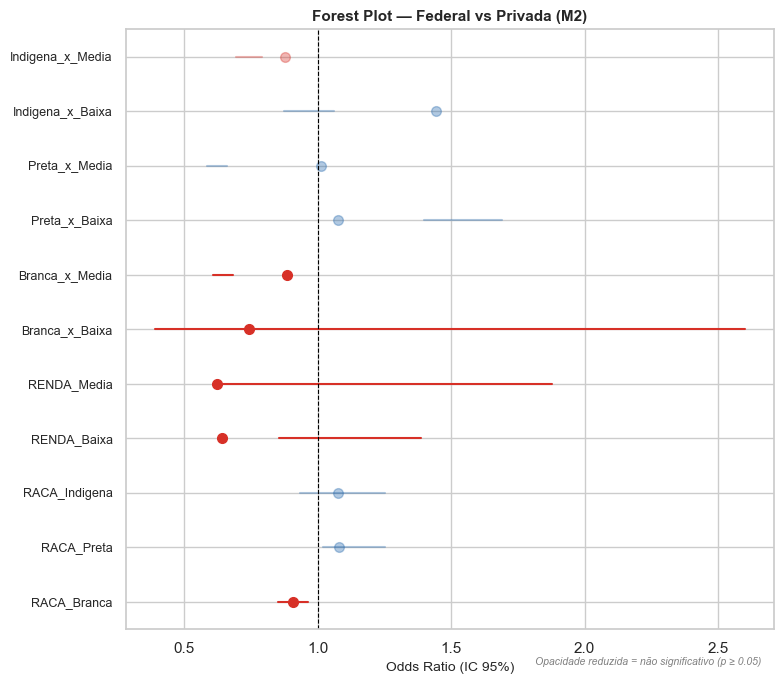

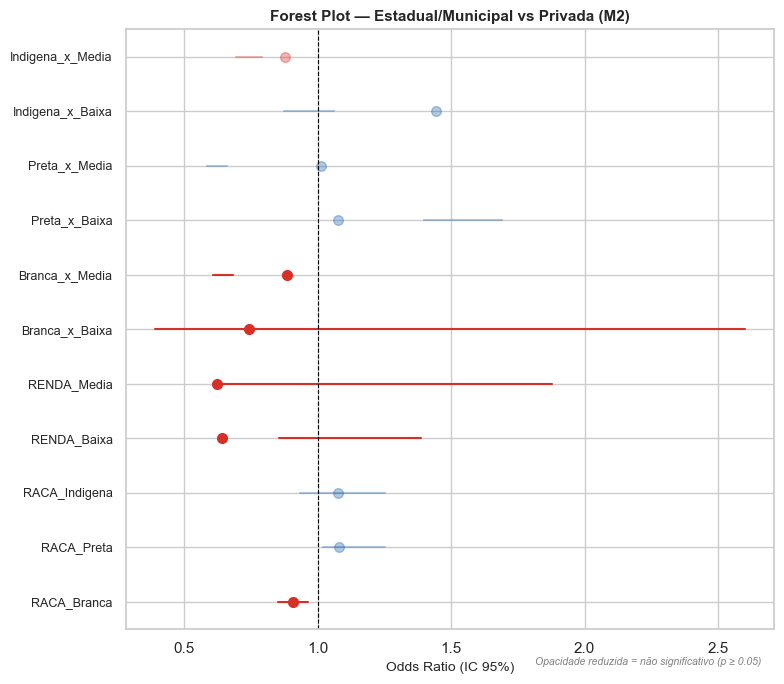

In [40]:
def forest_plot(model, cat=0, title='Forest Plot'):
    params  = m2.params.iloc[:, 0]
    pvalues = m2.pvalues.iloc[:, 0]
    conf    = m2.conf_int(0.05)
    ci_lo   = conf.iloc[:, 0]
    ci_hi   = conf.iloc[:, 1]

    # Flatten MultiIndex to simple index on all Series
    params.index  = params.index.get_level_values(-1)
    pvalues.index = pvalues.index.get_level_values(-1)
    ci_lo.index   = ci_lo.index.get_level_values(-1)
    ci_hi.index   = ci_hi.index.get_level_values(-1)

    idx = params.index.drop('const', errors='ignore')

    OR = np.exp(params[idx])
    lo = np.exp(ci_lo[idx])
    hi = np.exp(ci_hi[idx])
    pv = pvalues[idx]

    colors = ['#2166ac' if o > 1 else '#d73027' for o in OR]
    alpha  = [1.0 if p < 0.05 else 0.35 for p in pv]

    fig, ax = plt.subplots(figsize=(8, len(idx) * 0.5 + 1.5))

    for i, (var, or_, l, h, c, a) in enumerate(zip(idx, OR, lo, hi, colors, alpha)):
        ax.plot([l, h], [i, i], color=c, alpha=a, linewidth=1.5)
        ax.plot(or_, i, 'o', color=c, alpha=a, markersize=7)

    ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels(idx, fontsize=9)
    ax.set_xlabel('Odds Ratio (IC 95%)', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.text(0.98, -0.06, 'Opacidade reduzida = não significativo (p ≥ 0.05)',
            transform=ax.transAxes, ha='right', fontsize=7.5, color='gray', style='italic')
    plt.tight_layout()
    plt.show()

forest_plot(m2, cat=0, title='Forest Plot — Federal vs Privada (M2)')
forest_plot(m2, cat=1, title='Forest Plot — Estadual/Municipal vs Privada (M2)')

### 5.4 Probabilidades Preditas por Perfil

Visualiza a probabilidade predita de estar em cada tipo de IES para cada combinação de raça × renda.

In [26]:
# Cria todos os perfis raça × renda
perfis = pd.DataFrame([
    {'RACA': r, 'RENDA': rn}
    for r in ['Branca', 'Preta', 'Indigena', 'Outras']
    for rn in ['Baixa', 'Media', 'Alta']
])

for raca in ['Branca', 'Preta', 'Indigena']:
    perfis[f'RACA_{raca}']     = (perfis['RACA'] == raca).astype(int)
    perfis[f'{raca}_x_Baixa']  = perfis[f'RACA_{raca}'] * (perfis['RENDA'] == 'Baixa').astype(int)
    perfis[f'{raca}_x_Media']  = perfis[f'RACA_{raca}'] * (perfis['RENDA'] == 'Media').astype(int)

perfis['RENDA_Baixa'] = (perfis['RENDA'] == 'Baixa').astype(int)
perfis['RENDA_Media'] = (perfis['RENDA'] == 'Media').astype(int)

X_pred = sm.add_constant(perfis[X_cols], has_constant='add')
probs  = m2.predict(X_pred)
probs.columns = ['P(Privada)', 'P(Federal)', 'P(Estadual/Mun.)']

perfis_result = pd.concat([perfis[['RACA','RENDA']], probs], axis=1)
perfis_result = perfis_result.set_index(['RACA','RENDA'])
print(perfis_result.round(4).to_string())

                P(Privada)  P(Federal)  P(Estadual/Mun.)
RACA     RENDA                                          
Branca   Baixa      0.6941      0.1855            0.1204
         Media      0.6830      0.2108            0.1062
         Alta       0.5745      0.3219            0.1036
Preta    Baixa      0.5549      0.2566            0.1884
         Media      0.6187      0.2611            0.1203
         Alta       0.5428      0.3628            0.0944
Indigena Baixa      0.5104      0.3148            0.1748
         Media      0.6729      0.2438            0.0833
         Alta       0.5480      0.3639            0.0881
Outras   Baixa      0.6087      0.2421            0.1492
         Media      0.6499      0.2502            0.0999
         Alta       0.5626      0.3477            0.0897


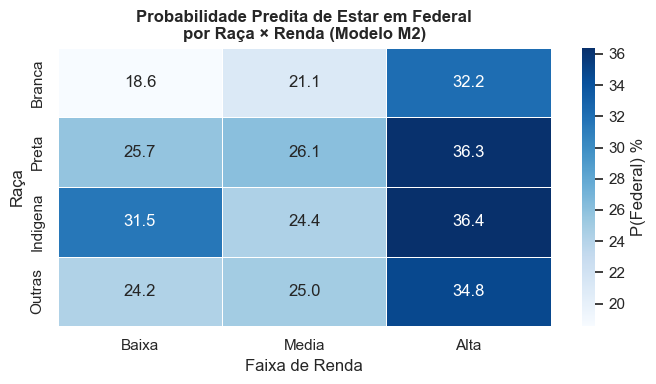

In [27]:
# Heatmap de P(Federal) por raça × renda
pivot_fed = (perfis_result['P(Federal)']
             .unstack()
             .loc[raca_order, renda_order] * 100)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_fed, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'P(Federal) %'})
ax.set_title('Probabilidade Predita de Estar em Federal\npor Raça × Renda (Modelo M2)',
             fontweight='bold')
ax.set_xlabel('Faixa de Renda')
ax.set_ylabel('Raça')
plt.tight_layout()
plt.show()

---
## 6. Sumário e Interpretação dos Resultados

### 6.1 Sumário do Modelo Final (M2)

In [28]:
print(m2.summary())

                          MNLogit Regression Results                          
Dep. Variable:                      Y   No. Observations:               428770
Model:                        MNLogit   Df Residuals:                   428746
Method:                           MLE   Df Model:                           22
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                0.007938
Time:                        01:19:58   Log-Likelihood:            -3.7383e+05
converged:                       True   LL-Null:                   -3.7682e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
             Y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.4813      0.028    -17.024      0.000      -0.537      -0.426
RACA_Branca         -0.0979      0.032     -3.072      0.002      -0.160      -0.035
RACA_Preta           0.0784 

### 6.2 Guia de Interpretação dos OR

| OR | Interpretação |
|---|---|
| OR > 1 | O grupo tem **maior chance** de estar na categoria vs Privada |
| OR < 1 | O grupo tem **menor chance** de estar na categoria vs Privada |
| OR = 1 | Sem diferença em relação à referência |

**Referências do modelo:**
- Raça: `Outras` (Amarela + Parda)
- Renda: `Alta` (>10 SM)
- IES: `Privada`

> Exemplo de leitura: *"Estudantes Pretos de Baixa Renda têm OR = X para Federal vs Privada — ou seja, X vezes a chance de estar em uma federal comparado a estudantes de raça Outras de Alta Renda."*

### 6.3 Conclusões

> Preencha após rodar o modelo com os dados reais:
>
> **Renda:** ...
>
> **Raça Preta:** ...
>
> **Raça Indígena:** ...
>
> **Raça Branca:** ...
>
> **Interação Raça × Renda:** ...